## Demo: linear manifold learning with PCA

Load the data

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import CIFAR10
import matplotlib.pyplot as plt

# Just changes how numbers display
torch.set_printoptions(sci_mode=False, precision=2)

def show_image(xs, scale=False):
    """Display flattened CIFAR-10 images."""
    n = len(xs)
    fig, axs = plt.subplots(1, n)
    a,b = xs.min(), xs.max()  # for min/max scaling
    if scale:
        xs = (xs-a) / (b-a)
    xs = torch.clamp(xs, 0., 1.)
    for i, ax in enumerate(axs):
        component = xs[i].reshape(3, 32, 32).moveaxis(0, -1)
        ax.imshow(component)
        ax.axis('off')
    return fig
    
# Load CIFAR-10 dataset using torchvision library
trainset = CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())
# Filter for dog images (dogs are labeled as 5)
dog_indices = [i for i, t in enumerate(trainset.targets) if t == 5]

# Create a DataLoader for the dog images
dog_dataset = Subset(trainset, dog_indices)
dog_loader = DataLoader(dog_dataset, batch_size=len(dog_dataset), shuffle=False)

# Extract dog images into a tensor
for images, _ in dog_loader:
    dog_images = images.view(images.size(0), -1)  # Flatten images

Files already downloaded and verified


In [2]:
dog_images.shape

torch.Size([5000, 3072])

In [3]:
# Center the dataset
mean = dog_images.mean(dim=0)
n = len(dog_images)  # number of images
dog_images = (dog_images - mean)

Actually perform PCA - we want the SVD of the covariance matrix

In [4]:
# Compute covariance matrix
cov_matrix = torch.mm(dog_images.t(), dog_images) / n

# Perform SVD
U, S, U_copy = torch.svd(cov_matrix)  # U_copy is identical to U, because cov is symmetric

Visualize / test the "components" and eigenvalues/variance of each

In [5]:
# Look at eigenvalues, check orthonormality, display principal components
S

tensor([   42.83,    21.13,    14.65,  ...,     0.00,     0.00,     0.00])

In [6]:
(U[:,0] * U[:,1]).sum()

tensor(    0.00)

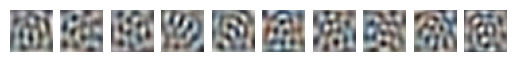

In [13]:
show_image(U[:,50:60].T, scale=True)  # show ten principal components

Reconstruct images using top k components

In [26]:
# First, use the linear model to project to low-d latent space
k = 1000

z = torch.mm(dog_images, U[:, :k])
print(dog_images.shape, z.shape)

torch.Size([5000, 3072]) torch.Size([5000, 1000])


original


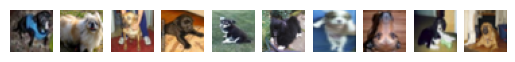

reconstruct using 1000 components


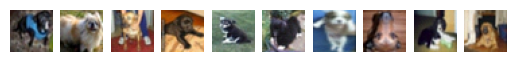

In [27]:
reconstructed_images = torch.mm(z, U[:, :k].t()) + mean  # linear decoder
fig1 = show_image(dog_images[:10]+mean, scale=False)
fig2 = show_image(reconstructed_images[:10], scale=False)
print('original')
display(fig1)
print(f'reconstruct using {k} components')
display(fig2)

Denoise an image

The linear manifold reconstruction can do some modest denoising

In [28]:
# noise = torch.randn(*shape)
noise = torch.randn_like(dog_images[:5])  # random numbers of same size/type/device
noisy_image = dog_images[:5] + 0.1 * noise  # std = 0.1

# Get latent factor
k = 500
z = torch.mm(noisy_image, U[:, :k])

print(z.shape)

torch.Size([5, 500])


In [32]:
# Dimension check
print(z.shape)

# (5, k=500) times (k=500, d=3072)
reconstructed_images = torch.mm(z, U[:, :k].t()) + mean  
print(reconstructed_images.shape)

torch.Size([5, 500])
torch.Size([5, 3072])


original dogs


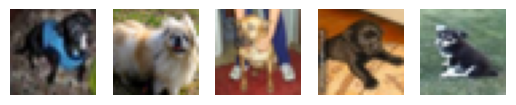

Noisy dogs


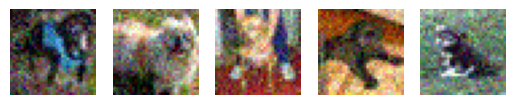

reconstruct using 500 components


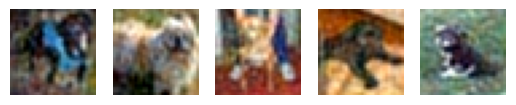

In [29]:
reconstructed_images = torch.mm(z, U[:, :k].t()) + mean  # decoder
fig0 = show_image(dog_images[:5] + mean, scale=False)  # original images
fig1 = show_image(noisy_image + mean, scale=False)  # images + noise
fig2 = show_image(reconstructed_images[:10], scale=False)  # reconstructed with linear autoencoder
print('original dogs')
display(fig0)
print('Noisy dogs')
display(fig1)
print(f'reconstruct using {k} components')
display(fig2)